# Plotting Time Series Models

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [182]:
# set folder with data
path = '../results/'
# get all files in the folder
all_files = glob.glob(path + "*.csv")

In [183]:
# filter the files that contain "covid"
covid_files = [f for f in all_files if 'covid' in f]
# filter the files that contain "epidemics"
epidemics_files = [f for f in all_files if 'epidemics' in f]

In [184]:
# get the original data
df_covid = pd.read_csv('../Data/silver/covid_data_weekly.csv')  

In [185]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,1/20/2020,0,0
1,Brazil,1/27/2020,0,0
2,Brazil,2/3/2020,0,0
3,Brazil,2/10/2020,0,0
4,Brazil,2/17/2020,0,0


In [186]:
nrow_dict = {}
for country in df_covid['country'].unique():
    df_temp = df_covid[df_covid['country'] == country]
    nrow_dict[country] = len(df_temp)

In [187]:
nrow_dict

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [188]:
from functools import reduce

# -------------------------------------------------------------------
# 1.  Load raw CSVs
# -------------------------------------------------------------------
df_dengue    = pd.read_csv('../Data/silver/dengue_no_split.csv')
df_zika      = pd.read_csv('../Data/silver/zika.csv').drop(columns=['Unnamed: 0'])
df_chic      = pd.read_csv('../Data/silver/chicunguya.csv').drop(columns=['Unnamed: 0'])
df_varicela  = pd.read_csv('../Data/silver/varicela.csv')

# -------------------------------------------------------------------
# 2.  Helper that:  (i) parses DATE  (ii) builds cumulative + t-1 series
# -------------------------------------------------------------------
def prep(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    df = df.copy()
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE')

    # cumulative sum of new weekly cases
    df[f'cum_{prefix}'] = df['Casos'].cumsum()

    # keep only the useful columns
    return df[['DATE', f'cum_{prefix}']]

# -------------------------------------------------------------------
# 3.  Prepare each disease frame
# -------------------------------------------------------------------
dengue   = prep(df_dengue,   'dengue')
zika     = prep(df_zika,     'zika')
chik     = prep(df_chic,     'chik')
varicela = prep(df_varicela, 'var')

# -------------------------------------------------------------------
# 4.  Outer-merge on DATE → aligns differing timelines, fills gaps with NaN
# -------------------------------------------------------------------
df_epidemics = reduce(
    lambda left, right: pd.merge(left, right, on='DATE', how='outer'),
    [dengue, zika, chik, varicela]
).sort_values('DATE').set_index('DATE')
df_epidemics.reset_index(inplace=True)
df_epidemics.rename(columns={'DATE': 'date',
                             'cum_dengue':'dengue',
                             'cum_zika':'zika',
                             'cum_chik':'chik',
                             'cum_var': 'var'}, inplace=True)
df_epidemics


,date,dengue,zika,chik,var
0,2007-01-01,315,NaN,NaN,250.0
1,2007-01-08,551,NaN,NaN,557.0
2,2007-01-15,803,NaN,NaN,858.0
3,2007-01-22,1108,NaN,NaN,1124.0
4,2007-01-29,1468,NaN,NaN,1481.0
...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0
891,2023-12-04,666895,NaN,78140.0,1201709.0
892,2023-12-11,670341,76165.0,78141.0,1202139.0
893,2023-12-18,673653,76167.0,78143.0,1202483.0


# Wrangle

## Covid

In [189]:
df_covid.tail()

,country,date,new_cases,cases
1635,Uruguay,2/6/2023,555,1033265
1636,Uruguay,2/13/2023,501,1033766
1637,Uruguay,2/20/2023,280,1034046
1638,Uruguay,2/27/2023,257,1034303
1639,Uruguay,3/6/2023,0,1034303


In [190]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,1/20/2020,0,0
1,Brazil,1/27/2020,0,0
2,Brazil,2/3/2020,0,0
3,Brazil,2/10/2020,0,0
4,Brazil,2/17/2020,0,0


In [191]:
dict_n_rows = {}
# count observations by country
for country in df_covid['country']:
    df_temp = df_covid[df_covid['country'] == country]
    dict_n_rows[country] = len(df_temp)

dict_n_rows

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [192]:
# ----------------------------------------------------------
# 1.  Make sure date is datetime & records are chronological
# ----------------------------------------------------------
df_covid['date'] = pd.to_datetime(df_covid['date'])
df_covid = df_covid.sort_values('date')

# ----------------------------------------------------------
# 2.  Pivot: rows = date, columns = country, values = cases
#     (all countries have the same number of observations)
# ----------------------------------------------------------
wide = (
    df_covid
      .pivot(index='date', columns='country', values='cases')
      .sort_index()                       # chronological index
)

# ----------------------------------------------------------
# 3.  Mark the first 80 % rows as TRAIN and the last 20 % as TEST
# ----------------------------------------------------------
split_point = int(len(wide) * 0.8)        # row where the 80/20 cut happens

wide['set'] = np.where(
    np.arange(len(wide)) < split_point,   # row-position test
    'train',
    'test'
)

# ----------------------------------------------------------
# 4.  (Optional) quick sanity check
# ----------------------------------------------------------
print(wide['set'].value_counts(normalize=True))
print(wide.head())


set
train    0.79878
test     0.20122
Name: proportion, dtype: float64
country     Brazil  Chile  Colombia  Dominican Republic  Germany  Italy  \
date                                                                      
2020-01-20       0      0         0                   0        0      0   
2020-01-27       0      0         0                   0       10      2   
2020-02-03       0      0         0                   0       14      3   
2020-02-10       0      0         0                   0       16      3   
2020-02-17       0      2         0                   0       16    155   

country     Mexico  Panama  US  Uruguay    set  
date                                            
2020-01-20       0       0   4        0  train  
2020-01-27       0       0   7        0  train  
2020-02-03       0       0  11        0  train  
2020-02-10       0       0  13        0  train  
2020-02-17       0       0  15        0  train  


In [193]:
wide.tail()

country,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,set
date,,,,,,,,,,,
2023-02-06,36932830,5138732,6355637,660412,37907312,25519067,7400848,1030214,102862878,1033265,test
2023-02-13,36987682,5149301,6356468,660492,38002114,25547414,7429778,1030658,103136076,1033766,test
2023-02-20,37020531,5163316,6357173,660533,38111063,25576852,7450992,1031014,103382762,1034046,test
2023-02-27,37081209,5180329,6358232,660705,38210851,25603510,7470653,1031273,103646974,1034303,test
2023-03-06,37081209,5192286,6359093,660790,38249060,25603510,7483444,1031731,103802701,1034303,test


In [194]:
df_covid_w = wide.copy().reset_index()

## Epidemics

In [195]:
# For each column in df_epidemics except 'date', create a new train/test split column.
# If the column contains NaNs, only the non-NaN entries are split by 80/20.
# The new column will be named "<original_column>_split".

for col in df_epidemics.columns:
    if col == 'date':
        continue
    series = df_epidemics[col]
    non_na = series.dropna()
    n = len(non_na)
    split_i = int(n * 0.8)
    split_labels = ['train'] * split_i + ['test'] * (n - split_i)
    
    # Initialize new split column with NaNs
    split_col = [np.nan] * len(series)
    
    # Get the indices of non-na values in order
    non_na_indices = non_na.index.tolist()
    for pos, row_idx in enumerate(non_na_indices):
        split_col[row_idx] = split_labels[pos]
    
    df_epidemics[col + '_split'] = split_col

df_epidemics

,date,dengue,zika,chik,var,dengue_split,zika_split,chik_split,var_split
0,2007-01-01,315,NaN,NaN,250.0,train,NaN,NaN,train
1,2007-01-08,551,NaN,NaN,557.0,train,NaN,NaN,train
2,2007-01-15,803,NaN,NaN,858.0,train,NaN,NaN,train
3,2007-01-22,1108,NaN,NaN,1124.0,train,NaN,NaN,train
4,2007-01-29,1468,NaN,NaN,1481.0,train,NaN,NaN,train
...,...,...,...,...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0,test,NaN,test,test
891,2023-12-04,666895,NaN,78140.0,1201709.0,test,NaN,test,test
892,2023-12-11,670341,76165.0,78141.0,1202139.0,test,test,test,test
893,2023-12-18,673653,76167.0,78143.0,1202483.0,test,test,test,test


# Plots

## Covid

In [196]:
df_covid_w.head()

country,date,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,set
0,2020-01-20,0,0,0,0,0,0,0,0,4,0,train
1,2020-01-27,0,0,0,0,10,2,0,0,7,0,train
2,2020-02-03,0,0,0,0,14,3,0,0,11,0,train
3,2020-02-10,0,0,0,0,16,3,0,0,13,0,train
4,2020-02-17,0,2,0,0,16,155,0,0,15,0,train


In [197]:
len(df_covid_w)

164

In [198]:
covid_files

['../results\\ARIMA_covid.csv',
 '../results\\BM_covid.csv',
 '../results\\DNN_covid.csv',
 '../results\\ElasticNet_covid.csv',
 '../results\\GB_covid.csv',
 '../results\\GGM-Arima_covid.csv',
 '../results\\GGM_covid.csv',
 '../results\\Lasso_covid.csv',
 '../results\\OLS_covid.csv',
 '../results\\PROPHET_covid.csv',
 '../results\\RF_covid.csv',
 '../results\\Ridge_covid.csv',
 '../results\\RNN_covid.csv',
 '../results\\SEIR_covid.csv',
 '../results\\SIR_covid.csv',
 '../results\\SVM_covid.csv']

In [199]:
# files you want to exclude
drop_these = {
    '../results\\OLS_covid.csv',
    '../results\\Lasso_covid.csv',
    '../results\\Ridge_covid.csv',
    '../results\\RidgeCV_covid.csv',
    '../results\\ElasticNet_covid.csv',
    '../results\\SVM_covid.csv',
    '../results\\GB_covid.csv',
    '../results\\RF_covid.csv',
    '../results\\DNN_covid.csv'
}

# keep everything that is *not* in drop_these
covid_files_ts = [f for f in covid_files if f not in drop_these]

print(covid_files_ts)


['../results\\ARIMA_covid.csv', '../results\\BM_covid.csv', '../results\\GGM-Arima_covid.csv', '../results\\GGM_covid.csv', '../results\\PROPHET_covid.csv', '../results\\RNN_covid.csv', '../results\\SEIR_covid.csv', '../results\\SIR_covid.csv']


In [200]:
covid_files_ts

['../results\\ARIMA_covid.csv',
 '../results\\BM_covid.csv',
 '../results\\GGM-Arima_covid.csv',
 '../results\\GGM_covid.csv',
 '../results\\PROPHET_covid.csv',
 '../results\\RNN_covid.csv',
 '../results\\SEIR_covid.csv',
 '../results\\SIR_covid.csv']

### Colombia

In [201]:
df_col = df_covid_w[['date', 'Colombia', 'set']].copy()
df_col

country,date,Colombia,set
0,2020-01-20,0,train
1,2020-01-27,0,train
2,2020-02-03,0,train
3,2020-02-10,0,train
4,2020-02-17,0,train
...,...,...,...
159,2023-02-06,6355637,test
160,2023-02-13,6356468,test
161,2023-02-20,6357173,test
162,2023-02-27,6358232,test


In [202]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in covid_files_ts:
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp_col = df_temp[['Colombia']]
    df_temp_col = df_temp_col.rename(columns={'Colombia': model})  # rename the column to the model name
    df_col = pd.concat([df_col, df_temp_col], axis=1)
    

In [203]:
df_col.rename(columns={'Colombia':'cases'}, inplace=True)  # rename the column to cases

In [204]:
df_col

,date,cases,set,arima,bm,ggm-arima,ggm,prophet,rnn,seir,sir
0,2020-01-20,0,train,4.555860e+01,6.443372e+03,1.098966e+02,1.729331e+03,-8.054501e+04,NaN,0,0
1,2020-01-27,0,train,1.093898e+04,1.328381e+04,9.177850e+02,4.954847e+03,-6.030733e+03,NaN,0,0
2,2020-02-03,0,train,1.838541e+03,2.054481e+04,1.211721e+03,9.224458e+03,2.048836e+04,NaN,0,0
3,2020-02-10,0,train,3.980353e+03,2.825115e+04,1.053257e+03,1.439753e+04,2.157715e+04,NaN,0,0
4,2020-02-17,0,train,3.107122e+03,3.642891e+04,1.403096e+03,2.040593e+04,1.745287e+04,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...
159,2023-02-06,6355637,test,7.459096e+06,6.250795e+06,6.703556e+06,6.708336e+06,7.447023e+06,6930052.5,10180411,5481699
160,2023-02-13,6356468,test,7.504647e+06,6.251953e+06,6.716586e+06,6.720171e+06,7.477474e+06,6949846.0,10182022,5481699
161,2023-02-20,6357173,test,7.550199e+06,6.253041e+06,6.729537e+06,6.731859e+06,7.506851e+06,6969470.0,10183446,5481699
162,2023-02-27,6358232,test,7.595753e+06,6.254065e+06,6.742323e+06,6.743404e+06,7.533388e+06,6988932.5,10184705,5481699


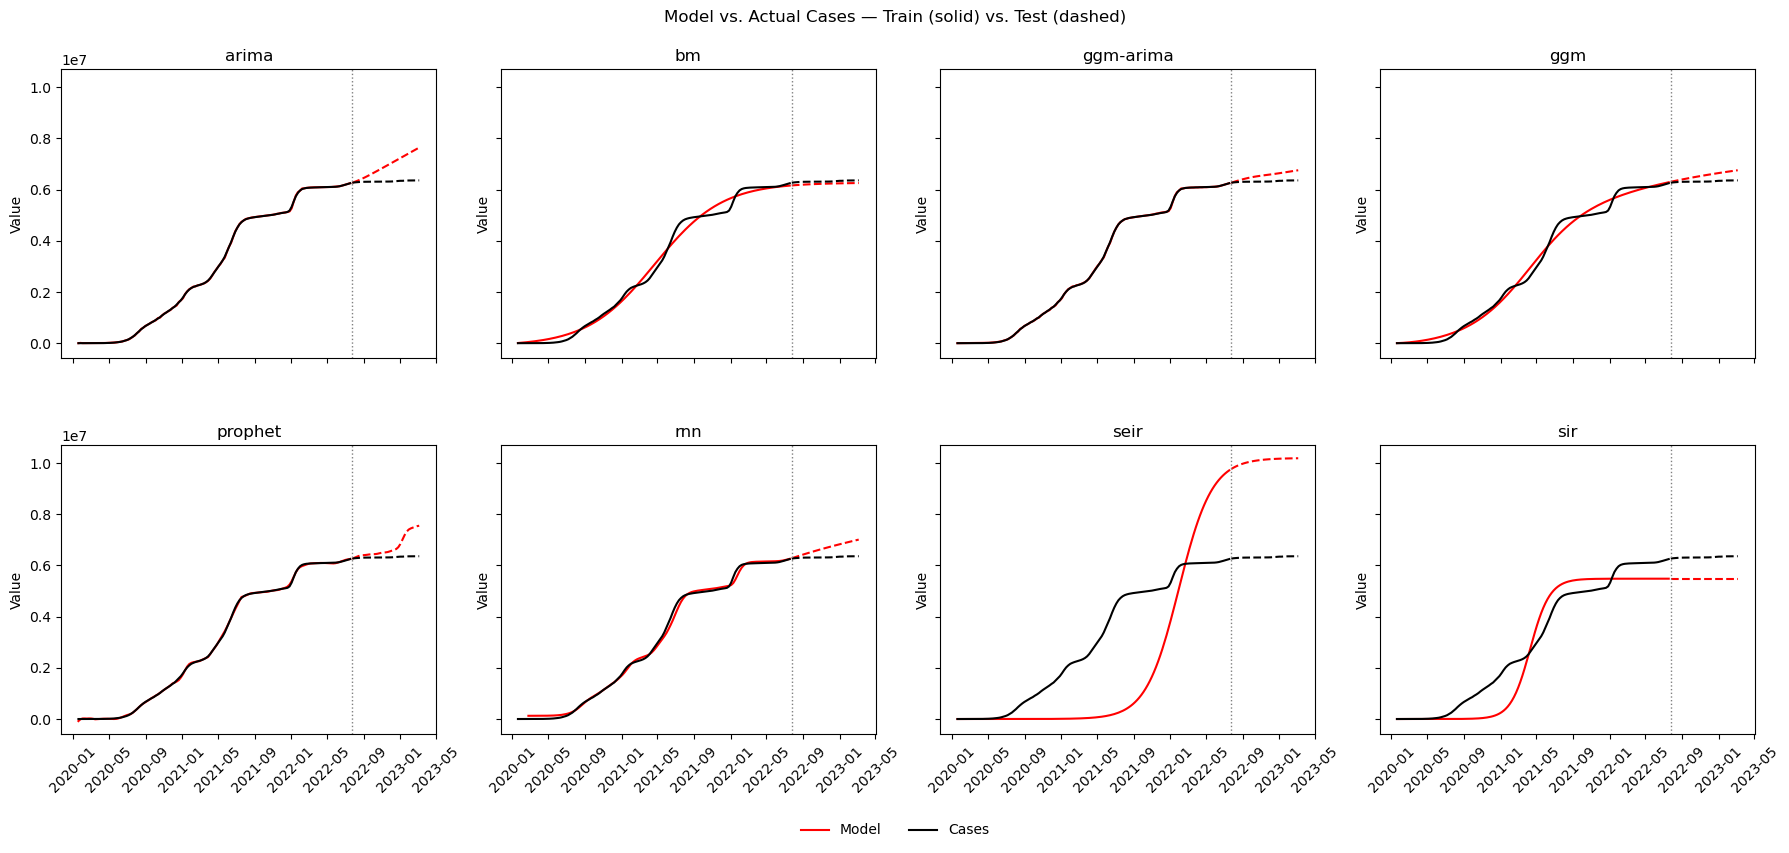

In [285]:
# ------------------------------------------------------------------
# 1.  Split into train / test & choose the 8 model columns
# ------------------------------------------------------------------
y_cols   = df_col.columns[3:]                     # 9 model columns 
train_df = df_col[df_col['set'] == 'train']
test_df  = df_col[df_col['set'] == 'test']

split_date = test_df['date'].min()               # first test date → vertical line

# ------------------------------------------------------------------
# 2.  2 × 4 grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, y_cols)):
    # --------------------------------------------------------------
    # Model predictions : red
    # --------------------------------------------------------------
    lbl_model = 'Model' if i == 0 else None
    ax.plot(train_df['date'], train_df[col],  color='red', label=lbl_model)
    ax.plot(test_df['date'],  test_df[col],   color='red', linestyle='--')

    # --------------------------------------------------------------
    # Actual cases       : black
    # --------------------------------------------------------------
    lbl_cases = 'Cases' if i == 0 else None
    ax.plot(train_df['date'], train_df['cases'], color='black', label=lbl_cases)
    ax.plot(test_df['date'],  test_df['cases'],  color='black', linestyle='--')

    # vertical separator
    ax.axvline(split_date, color='grey', linestyle=':', lw=1)

    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------
# 3.  Shared legend (labels defined only in first subplot)
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])   # leave space below for legend
fig.suptitle('Model vs. Actual Cases — Train (solid) vs. Test (dashed)', y=1.03)
plt.subplots_adjust(hspace=0.3)  # space between rows
plt.show()

## Epidemics

In [206]:
epidemics_files

['../results\\ARIMA_epidemics.csv',
 '../results\\BM_epidemics.csv',
 '../results\\DNN_epidemics.csv',
 '../results\\ElasticNet_epidemics.csv',
 '../results\\GB_epidemics.csv',
 '../results\\GGM-ARIMA_epidemics.csv',
 '../results\\GGM_epidemics.csv',
 '../results\\Lasso_epidemics.csv',
 '../results\\OLS_epidemics.csv',
 '../results\\PROPHET_epidemics.csv',
 '../results\\RF_epidemics.csv',
 '../results\\Ridge_epidemics.csv',
 '../results\\RNN_epidemics.csv',
 '../results\\SEIR_epidemics.csv',
 '../results\\SIR_epidemics.csv',
 '../results\\SVM_epidemics.csv']

In [207]:
# files you want to exclude
drop_these = {
    '../results\\OLS_epidemics.csv',
    '../results\\Lasso_epidemics.csv',
    '../results\\Ridge_epidemics.csv',
    '../results\\RidgeCV_epidemics.csv',
    '../results\\ElasticNet_epidemics.csv',
    '../results\\SVM_epidemics.csv',
    '../results\\GB_epidemics.csv',
    '../results\\RF_epidemics.csv',
    '../results\\DNN_epidemics.csv',
}

# keep everything that is *not* in drop_these
epidemics_files_ts = [f for f in epidemics_files if f not in drop_these]

epidemics_files_ts

['../results\\ARIMA_epidemics.csv',
 '../results\\BM_epidemics.csv',
 '../results\\GGM-ARIMA_epidemics.csv',
 '../results\\GGM_epidemics.csv',
 '../results\\PROPHET_epidemics.csv',
 '../results\\RNN_epidemics.csv',
 '../results\\SEIR_epidemics.csv',
 '../results\\SIR_epidemics.csv']

### Dengue

In [208]:
df_dengue = df_epidemics[['date', 'dengue', 'dengue_split']].copy()
df_dengue.rename(columns={'dengue_split': 'set'}, inplace=True)
df_dengue['date'] = pd.to_datetime(df_dengue['date'])
df_dengue

,date,dengue,set
0,2007-01-01,315,train
1,2007-01-08,551,train
2,2007-01-15,803,train
3,2007-01-22,1108,train
4,2007-01-29,1468,train
...,...,...,...
890,2023-11-27,663526,test
891,2023-12-04,666895,test
892,2023-12-11,670341,test
893,2023-12-18,673653,test


In [209]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
'''for file in epidemics_files_ts:
    print('processing file: ', file)
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp_d = df_temp.iloc[:, :2]  # get only the first two columns
    df_temp_d.columns = ['date', model]
    #print(df_temp_d.head(2))
    
    print(file,'has len: ',len(df_temp_d))
    df_dengue = pd.concat([df_col, df_temp_d], axis=1)'''

"for file in epidemics_files_ts:\n    print('processing file: ', file)\n    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name\n    model  = model.lower()  # convert to lower case\n    df_temp = pd.read_csv(file)\n    df_temp['date'] = pd.to_datetime(df_temp['date'])\n    df_temp_d = df_temp.iloc[:, :2]  # get only the first two columns\n    df_temp_d.columns = ['date', model]\n    #print(df_temp_d.head(2))\n    \n    print(file,'has len: ',len(df_temp_d))\n    df_dengue = pd.concat([df_col, df_temp_d], axis=1)"

In [210]:
df_arima_d = pd.read_csv('../results/ARIMA_epidemics.csv')
df_arima_d['date'] = pd.to_datetime(df_arima_d['date'])
df_arima_d = df_arima_d[['date', 'Dengue']]
df_arima_d.rename(columns={'Dengue': 'arima'}, inplace=True)
df_arima_d.head()


,date,arima
0,2007-01-01,314.859128
1,2007-01-08,550.894905
2,2007-01-15,787.258660
3,2007-01-22,1055.390161
4,2007-01-29,1411.422632


In [211]:
df_bm_d = pd.read_csv('../results/BM_epidemics.csv')
df_bm_d['date'] = pd.to_datetime(df_bm_d['date'])
df_bm_d = df_bm_d[['date', 'Dengue']]
df_bm_d.rename(columns={'Dengue': 'bm'}, inplace=True)
df_bm_d.head()

,date,bm
0,2007-01-01,302.977332
1,2007-01-08,607.161057
2,2007-01-15,912.554537
3,2007-01-22,1219.161131
4,2007-01-29,1526.984194


In [212]:
df_ggm_arima_d = pd.read_csv('../results/GGM-ARIMA_epidemics.csv')
df_ggm_arima_d['date'] = pd.to_datetime(df_ggm_arima_d['DATE'])
df_ggm_arima_d = df_ggm_arima_d[['date', 'Dengue']]
df_ggm_arima_d.rename(columns={'Dengue': 'ggm_arima'}, inplace=True)
df_ggm_arima_d.head()

,date,ggm_arima
0,2007-01-01,499.850485
1,2007-01-08,562.355295
2,2007-01-15,912.500716
3,2007-01-22,1086.769997
4,2007-01-29,1526.749869


In [213]:
df_ggm_d = pd.read_csv('../results/GGM_epidemics.csv')
df_ggm_d['date'] = pd.to_datetime(df_ggm_d['date'])
df_ggm_d = df_ggm_d[['date', 'Dengue']]
df_ggm_d.rename(columns={'Dengue': 'ggm'}, inplace=True)
df_ggm_d.head()

,date,ggm
0,2007-01-01,27.953391
1,2007-01-08,79.136904
2,2007-01-15,145.516986
3,2007-01-22,224.242392
4,2007-01-29,313.672778


In [214]:
df_prophet_d = pd.read_csv('../results/Prophet_epidemics.csv')
df_prophet_d['date'] = pd.to_datetime(df_prophet_d['date'])
df_prophet_d = df_prophet_d[['date', 'Dengue']]
df_prophet_d.rename(columns={'Dengue': 'prophet'}, inplace=True)
df_prophet_d.head()

,date,prophet
0,2007-01-01,-999.492237
1,2007-01-08,-615.110023
2,2007-01-15,-201.506938
3,2007-01-22,278.682162
4,2007-01-29,805.598525


In [215]:
df_rnn_d = pd.read_csv('../results/RNN_epidemics.csv')
df_rnn_d['date'] = pd.to_datetime(df_rnn_d['date'])
df_rnn_d = df_rnn_d[['date', 'Dengue']]
df_rnn_d.rename(columns={'Dengue': 'rnn'}, inplace=True)
df_rnn_d.head()

,date,rnn
0,2007-01-01,2993.549561
1,2007-01-08,2993.549561
2,2007-01-15,2993.549561
3,2007-01-22,2993.549561
4,2007-01-29,2993.549561


In [216]:
df_seir_d = pd.read_csv('../results/SEIR_epidemics.csv')
df_seir_d['date'] = pd.to_datetime(df_seir_d['date'])
df_seir_d = df_seir_d[['date', 'dengue_no_split']]
df_seir_d.rename(columns={'dengue_no_split': 'seir'}, inplace=True)
df_seir_d.head()

,date,seir
0,2007-01-01,945.000000
1,2007-01-08,1624.050590
2,2007-01-15,1997.940927
3,2007-01-22,2372.782641
4,2007-01-29,2748.577049


In [217]:
df_sir_d = pd.read_csv('../results/SIR_epidemics.csv')
df_sir_d['date'] = pd.to_datetime(df_sir_d['date'])
df_sir_d = df_sir_d[['date', 'dengue_no_split']]
df_sir_d.rename(columns={'dengue_no_split': 'sir'}, inplace=True)
df_sir_d.head()

,date,sir
0,2007-01-01,315.000000
1,2007-01-08,598.578594
2,2007-01-15,883.411668
3,2007-01-22,1169.503309
4,2007-01-29,1456.857605


In [218]:
df_dengue.head()

,date,dengue,set
0,2007-01-01,315,train
1,2007-01-08,551,train
2,2007-01-15,803,train
3,2007-01-22,1108,train
4,2007-01-29,1468,train


In [219]:
# merge all dataframes on date
df_dengue = pd.merge(df_dengue, df_arima_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_bm_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_ggm_arima_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_ggm_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_prophet_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_rnn_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_seir_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_sir_d, on='date', how='outer')
df_dengue = df_dengue.sort_values('date')

In [220]:
df_dengue

,date,dengue,set,arima,bm,ggm_arima,ggm,prophet,rnn,seir,sir
0,2007-01-01,315.0,train,314.859128,302.977332,499.850485,27.953391,-999.492237,2993.549561,945.000000,315.000000
1,2007-01-08,551.0,train,550.894905,607.161057,562.355295,79.136904,-615.110023,2993.549561,1624.050590,598.578594
2,2007-01-15,803.0,train,787.258660,912.554537,912.500716,145.516986,-201.506938,2993.549561,1997.940927,883.411668
3,2007-01-22,1108.0,train,1055.390161,1219.161131,1086.769997,224.242392,278.682162,2993.549561,2372.782641,1169.503309
4,2007-01-29,1468.0,train,1411.422632,1526.984194,1526.749869,313.672778,805.598525,2993.549561,2748.577049,1456.857605
...,...,...,...,...,...,...,...,...,...,...,...
34672,2023-11-27,663526.0,test,532068.080700,519924.213832,580772.978600,582173.721466,652179.453794,489482.750000,574693.748096,507327.135234
34673,2023-12-04,666895.0,test,532334.024600,520197.688198,581463.643400,582868.455910,653018.910028,489482.750000,575237.905363,507552.402139
34674,2023-12-11,670341.0,test,532599.968500,520470.045835,582154.378200,583563.260748,653980.574694,489482.750000,575781.006671,507776.627719
34675,2023-12-18,673653.0,test,532865.912400,520741.290155,582845.183900,584258.136965,655058.501506,489482.750000,576323.051779,507999.815910


In [221]:
df_dengue = df_dengue[['date', 'set', 'dengue', 'arima', 'bm', 'ggm_arima', 'ggm', 'prophet',
       'rnn', 'seir', 'sir']]
df_dengue.rename(columns = {'dengue': 'cases'}, inplace=True)

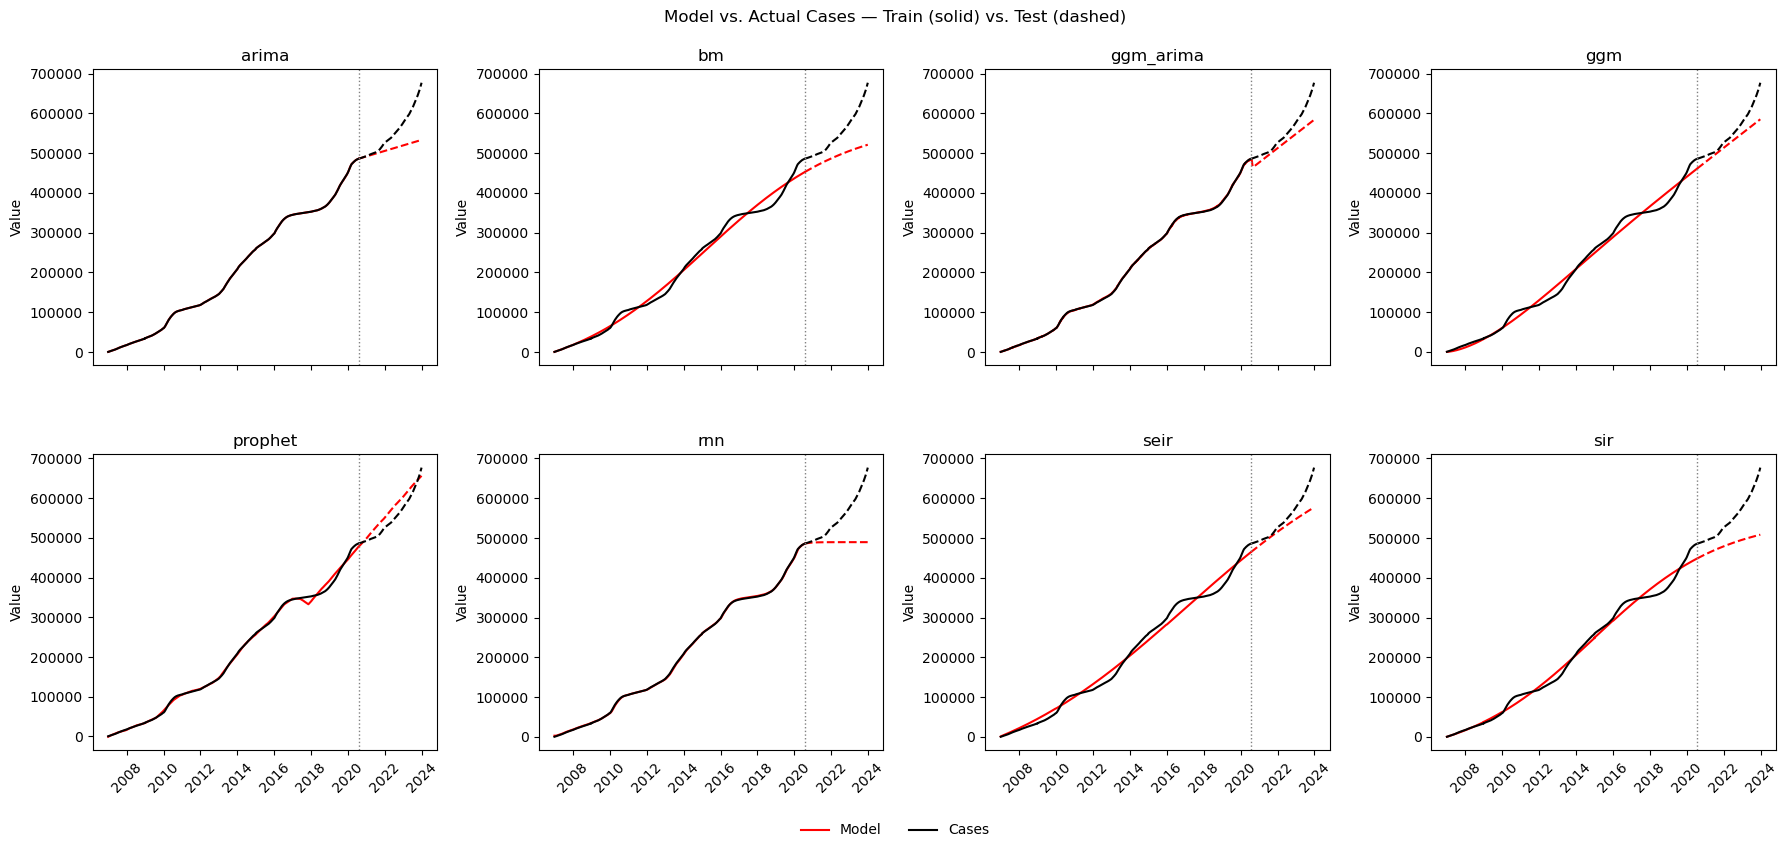

In [222]:
# ------------------------------------------------------------------
# 1.  Split into train / test & choose the 8 model columns
# ------------------------------------------------------------------
y_cols   = df_dengue.columns[3:]                     # 9 model columns 
train_df = df_dengue[df_dengue['set'] == 'train']
test_df  = df_dengue[df_dengue['set'] == 'test']
split_date = test_df['date'].min()               # first test date → vertical line


# ------------------------------------------------------------------
# 2.  2 × 4 grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, y_cols)):
    # --------------------------------------------------------------
    # Model predictions : red
    # --------------------------------------------------------------
    lbl_model = 'Model' if i == 0 else None
    ax.plot(train_df['date'], train_df[col],  color='red', label=lbl_model)
    ax.plot(test_df['date'],  test_df[col],   color='red', linestyle='--')

    # --------------------------------------------------------------
    # Actual cases       : black
    # --------------------------------------------------------------
    lbl_cases = 'Cases' if i == 0 else None
    ax.plot(train_df['date'], train_df['cases'], color='black', label=lbl_cases)
    ax.plot(test_df['date'],  test_df['cases'],  color='black', linestyle='--')

    # vertical separator
    ax.axvline(split_date, color='grey', linestyle=':', lw=1)

    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------
# 3.  Shared legend (labels defined only in first subplot)
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])   # leave space below for legend
fig.suptitle('Model vs. Actual Cases — Train (solid) vs. Test (dashed)', y=1.03)
plt.subplots_adjust(hspace=0.3)  # space between rows
plt.show()

# Metrics

In [223]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [231]:
df_base = pd.DataFrame()

In [232]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in covid_files_ts:
    print('processing file: ', file)
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp_long = df_temp.melt(id_vars=['date'], var_name='country', value_name='value')
    df_temp_long['model'] = model
    df_base = pd.concat([df_base, df_temp_long], axis=0)
    

processing file:  ../results\ARIMA_covid.csv
processing file:  ../results\BM_covid.csv
processing file:  ../results\GGM-Arima_covid.csv
processing file:  ../results\GGM_covid.csv
processing file:  ../results\PROPHET_covid.csv
processing file:  ../results\RNN_covid.csv
processing file:  ../results\SEIR_covid.csv
processing file:  ../results\SIR_covid.csv


In [242]:
df_covid_temp = df_covid[['date', 'country', 'cases']].copy()
df_covid_temp['date'] = pd.to_datetime(df_covid_temp['date'])

In [250]:
r2_metrics = {}
countries = df_base['country'].unique()
country = countries[2]
models = df_base['model'].unique()
model = models[0]
df_fitted_temp = df_base[(df_base['country'] == country) & (df_base['model'] == model)].copy()
df_fitted_temp.head()

y_true = df_covid_temp[(df_covid_temp['country'] == country)]['cases']
y_pred = df_fitted_temp['value']
# split the data into train and test by 80/20
split_point = int(len(y_true) * 0.8)        # row where the 80/20 cut happens
y_test_true = y_true[split_point:]
y_pred_test = y_pred[split_point:]
# calculate the metrics
rmse = np.sqrt(mean_squared_error(y_test_true, y_pred_test))
r2 = r2_score(y_test_true, y_pred_test)
r2_metrics[country] = [model, r2]
r2_metrics


{'Colombia': ['arima', -844.0990904016917]}

In [ ]:
countries = df_base['country'].unique()
models = df_base['model'].unique()
n_countries = len(countries)
n_models = len(models)
rmse_matrix = np.zeros((n_countries, n_models))
r2_matrix = np.zeros((n_countries, n_models))

# ESTE LOOP ESTA MAL / REVISAR

In [ ]:
countries = df_base['country'].unique()
models = df_base['model'].unique()

y_true = df_covid_temp[(df_covid_temp['country'] == country)]['cases']
split_point = int(len(y_true) * 0.8)        # row where the 80/20 cut happens
y_test_true = y_true[split_point:]

for i in range(n_countries):
    country = countries[i]
    for j in range(n_models):
        model = models[j]
        # get the test data for the country i and model j
        df_fitted_temp = df_base[(df_base['country'] == country) & (df_base['model'] == model)].copy()
        y_pred = df_fitted_temp['value']
        y_pred_test = y_pred[split_point:]
        
        # calculate the metrics
        rmse = np.sqrt(mean_squared_error(y_test_true, y_pred_test))
        r2 = r2_score(y_test_true, y_pred_test)
        rmse_matrix[i,j] = rmse
        r2_matrix[i,j] = r2
        
# create a dataframe with the metrics
df_rmse = pd.DataFrame(rmse_matrix, columns=models, index=countries)
df_r2 = pd.DataFrame(r2_matrix, columns=models, index=countries)

In [ ]:
df_rmse_t = df_rmse.transpose()
df_r2_t = df_r2.transpose()
# create mean columns
df_rmse_t['mean'] = df_rmse_t.mean(axis=1)
df_r2_t['mean'] = df_r2_t.mean(axis=1)

## Control Colombia

In [302]:
df_covid_temp_col = df_covid_temp[df_covid_temp['country'] == 'Colombia'].copy().reset_index(drop=True)

In [309]:
split_idx = int(len(df_covid_temp_col) * 0.8)
df_covid_temp_col_train = df_covid_temp_col[:split_idx]
df_covid_temp_col_test = df_covid_temp_col[split_idx:]
y_true = df_covid_temp_col_test['cases']

In [310]:
df_col_pred = df_base[(df_base['country'] == 'Colombia')].copy()
df_col_pred.head()

,date,country,value,model
328,2020-01-20,Colombia,45.558599,arima
329,2020-01-27,Colombia,10938.984440,arima
330,2020-02-03,Colombia,1838.540849,arima
331,2020-02-10,Colombia,3980.352816,arima
332,2020-02-17,Colombia,3107.121780,arima


In [314]:
dict_metrics_col = {}
models = df_col_pred['model'].unique()
for model in models:
    df_aux = df_col_pred[df_col_pred['model'] == model].copy()
    y_pred = df_aux['value']
    y_pred_test = y_pred[split_idx:]
    
    # calculate the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_test))
    dict_metrics_col[model] = rmse

In [317]:
# dict_metrics_col to dataframe
df_metrics_col = pd.DataFrame.from_dict(dict_metrics_col, orient='index', columns=['rmse'])
df_metrics_col = df_metrics_col.reset_index()
df_metrics_col.sort_values(by='rmse', ascending=True, inplace=True)

In [318]:
df_metrics_col

,index,rmse
1,bm,9.881708e+04
3,ggm,2.502210e+05
2,ggm-arima,2.511095e+05
5,rnn,3.947874e+05
4,prophet,5.704205e+05
0,arima,7.209882e+05
7,sir,8.393105e+05
6,seir,3.763591e+06


<BarContainer object of 8 artists>

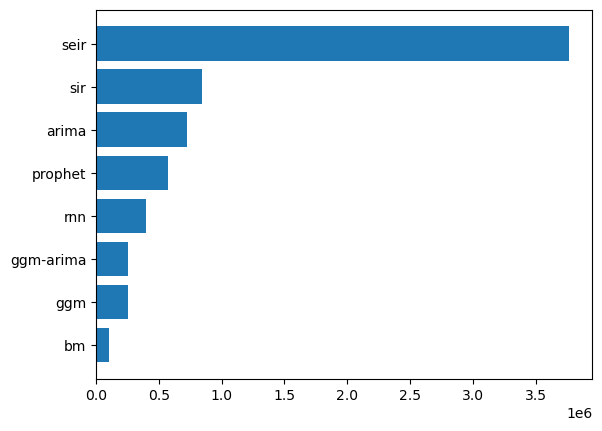

In [319]:
plt.barh(df_metrics_col['index'], df_metrics_col['rmse'])

# CHECK

En el grafico BM, GGM y GGM + ARIMA son mejores pero en el rmse el SIR?

<BarContainer object of 8 artists>

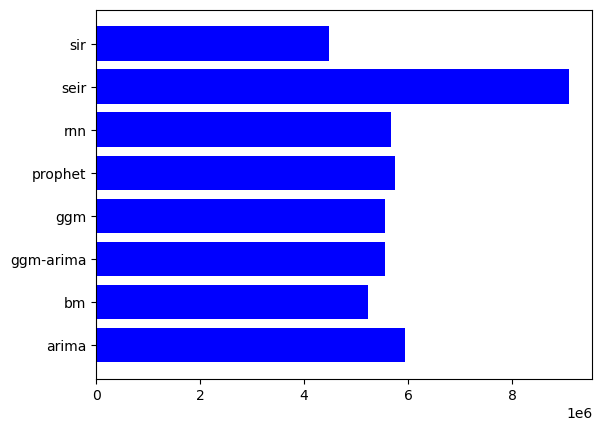

In [288]:
plt.barh(df_rmse_t.index, df_rmse_t['Colombia'], color='blue')